# 01 – Exploration des données et extraction de features

**Auteur :** Grégory CRESPIN  
**Projet :** Labellisez et appliquez des approches semi-supervisées en traitement d'images  
**Nom court :** BrainScanAI  
**Date :** 08/02/2026

Objectifs :
1. Charger et explorer le jeu de données (structure, résolution, canaux).
2. Préparer les images (redimensionnement, normalisation) pour un modèle type ConvNeXt.
3. Extraire des embeddings visuels avec un modèle pré-entraîné et les sauvegarder.

In [1]:
# ============================================
# IMPORTATION DES BIBLIOTHÈQUES
# ============================================
# sys : permet de modifier le chemin de recherche des modules Python
import sys
# Path : classe pour manipuler les chemins de fichiers de manière portable (Windows/Linux/Mac)
from pathlib import Path
# numpy : bibliothèque pour les calculs numériques et tableaux multidimensionnels
import numpy as np
# pandas : bibliothèque pour manipuler des données structurées (DataFrames, CSV, etc.)
import pandas as pd
# matplotlib.pyplot : bibliothèque pour créer des graphiques et visualisations
import matplotlib.pyplot as plt
# PIL.Image : bibliothèque pour ouvrir, manipuler et sauvegarder des images
from PIL import Image
# torch : bibliothèque PyTorch pour le deep learning
import torch
# torch.nn : module contenant les couches de réseaux de neurones
import torch.nn as nn
# torchvision.models : modèles pré-entraînés (ConvNeXt, ResNet, VGG, etc.)
# torchvision.transforms : transformations d'images (redimensionnement, normalisation, etc.)
from torchvision import models, transforms
# tqdm : barre de progression pour suivre l'avancement des boucles
from tqdm import tqdm

# Ajouter le répertoire courant au chemin de recherche Python
# Cela permet d'importer le module config.py qui se trouve dans le même dossier
sys.path.insert(0, str(Path.cwd()))
# Importer notre fichier de configuration qui contient tous les chemins et paramètres
import config

## 1. Chargement et exploration du jeu de données

In [2]:
def collect_image_paths():
    """Collecte les chemins des images labellisées et non labellisées."""
    # Initialiser deux listes vides pour stocker les chemins et les labels
    labeled_paths, labeled_labels = [], []
    
    # Parcourir chaque classe (normal, cancer) définie dans config.CLASSES
    for cls in config.CLASSES:
        # Construire le chemin du dossier pour cette classe (ex: datapic/avec_labels/normal)
        folder = config.LABELED_DIR / cls
        # Vérifier si le dossier existe avant de continuer
        if not folder.exists():
            continue  # Passer à la classe suivante si le dossier n'existe pas
        # Chercher tous les fichiers .jpg dans ce dossier avec glob()
        for p in folder.glob("*.jpg"):
            # Ajouter le chemin complet de l'image à la liste
            labeled_paths.append(p)
            # Ajouter le label correspondant (normal ou cancer)
            labeled_labels.append(cls)
    
    # Chercher tous les fichiers .jpg dans le dossier des images non labellisées
    # list() convertit le résultat de glob() en liste Python
    unlabeled_paths = list(config.UNLABELED_DIR.glob("*.jpg"))
    
    # Retourner les trois listes
    return labeled_paths, labeled_labels, unlabeled_paths

# Appeler la fonction et récupérer les résultats
labeled_paths, labeled_labels, unlabeled_paths = collect_image_paths()

# Créer un DataFrame pandas pour organiser les données labellisées
# Un DataFrame est comme un tableau Excel : colonnes "path" et "label"
df_labeled = pd.DataFrame({"path": labeled_paths, "label": labeled_labels})

# Afficher le nombre total d'images labellisées
print("Images labellisées:", len(df_labeled))
# Afficher le nombre d'images par classe (normal vs cancer)
print(df_labeled["label"].value_counts())
# Afficher le nombre d'images non labellisées
print("Images non labellisées:", len(unlabeled_paths))

Images labellisées: 100
label
normal    50
cancer    50
Name: count, dtype: int64
Images non labellisées: 1406


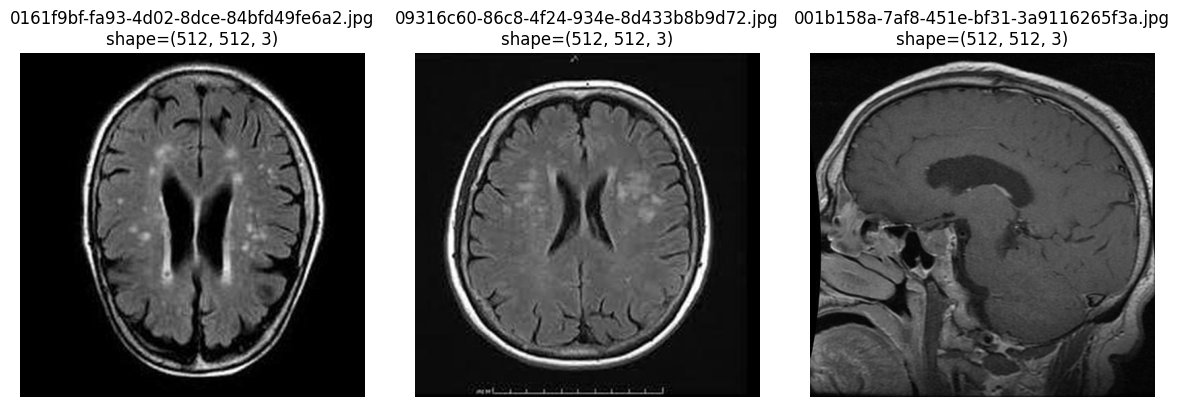

In [3]:
# Sélectionner quelques exemples d'images pour les visualiser
# head(2) prend les 2 premières images labellisées
sample_paths = list(df_labeled["path"].head(2)) + [unlabeled_paths[0]]

# Créer une figure avec 3 sous-graphiques côte à côte (1 ligne, 3 colonnes)
# figsize=(12, 4) définit la taille : 12 pouces de large, 4 pouces de haut
fig, axes = plt.subplots(1, 3, figsize=(12, 4))

# Parcourir chaque image et son axe correspondant
# zip() associe chaque chemin d'image avec son axe de graphique
for ax, p in zip(axes, sample_paths):
    # Ouvrir l'image avec PIL et la convertir en tableau numpy
    # np.array() convertit l'image PIL en tableau de pixels
    img = np.array(Image.open(p))
    
    # Afficher l'image sur l'axe
    # cmap="gray" : utiliser une palette de gris si l'image est en niveaux de gris
    # Si img.ndim == 2, c'est une image en niveaux de gris (2 dimensions : hauteur x largeur)
    # Sinon, c'est une image couleur (3 dimensions : hauteur x largeur x canaux RGB)
    ax.imshow(img, cmap="gray" if img.ndim == 2 else None)
    
    # Définir le titre du graphique avec le nom du fichier et la forme de l'image
    ax.set_title(f"{p.name}\nshape={img.shape}")
    
    # Masquer les axes (enlever les graduations autour de l'image)
    ax.axis("off")

# Ajuster automatiquement l'espacement entre les graphiques pour éviter le chevauchement
plt.tight_layout()
# Afficher la figure
plt.show()

## 2. Préprocessing et transform pour ConvNeXt

In [4]:
# ============================================
# PRÉPARATION DES TRANSFORMATIONS D'IMAGES
# ============================================
# ConvNeXt attend des images de taille 224x224 pixels et normalisées avec des valeurs spécifiques

# transforms.Compose() : chaîne plusieurs transformations qui seront appliquées dans l'ordre
transform_convnext = transforms.Compose([
    # Resize : redimensionner l'image à 224x224 pixels (taille d'entrée standard de ConvNeXt)
    transforms.Resize((config.RESIZE_FOR_MODEL, config.RESIZE_FOR_MODEL)),
    
    # ToTensor() : convertir l'image PIL en tenseur PyTorch
    # Les valeurs des pixels passent de [0, 255] à [0.0, 1.0] (float)
    # L'ordre des dimensions change : (H, W, C) devient (C, H, W) où C=canaux (RGB)
    transforms.ToTensor(),
    
    # Normalize : normaliser chaque canal RGB avec la moyenne et l'écart-type d'ImageNet
    # Ces valeurs sont celles utilisées lors de l'entraînement de ConvNeXt sur ImageNet
    # mean=[0.485, 0.456, 0.406] : moyennes pour R, G, B
    # std=[0.229, 0.224, 0.225] : écarts-types pour R, G, B
    # Formule : pixel_normalisé = (pixel - mean) / std
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

def load_and_transform(path, transform):
    """
    Charge une image depuis un chemin et applique les transformations.
    
    Args:
        path: chemin vers l'image
        transform: pipeline de transformations à appliquer
    
    Returns:
        Tenseur PyTorch de l'image transformée avec une dimension batch ajoutée
    """
    # Ouvrir l'image et s'assurer qu'elle est en RGB (3 canaux)
    # convert("RGB") garantit 3 canaux même si l'image originale est en niveaux de gris
    img = Image.open(path).convert("RGB")
    
    # Appliquer les transformations (redimensionnement, normalisation, etc.)
    transformed = transform(img)
    
    # unsqueeze(0) ajoute une dimension batch au début
    # De (C, H, W) on passe à (1, C, H, W)
    # Le modèle attend des batches, donc même pour une seule image, on ajoute cette dimension
    return transformed.unsqueeze(0)

## 3. Extraction des features avec ConvNeXt pré-entraîné

In [5]:
def get_convnext_encoder(feature_layer="avgpool"):
    """
    Charge ConvNeXt pré-entraîné et retourne seulement la partie qui extrait les features.
    
    Args:
        feature_layer: quelle couche utiliser pour extraire les features
                      "avgpool" = dernière couche avant la classification
    
    Returns:
        Modèle ConvNeXt sans la couche de classification finale
    """
    # Charger ConvNeXt Base pré-entraîné sur ImageNet
    # weights=IMAGENET1K_V1 : utiliser les poids pré-entraînés officiels
    model = models.convnext_base(weights=models.ConvNeXt_Base_Weights.IMAGENET1K_V1)
    
    # Geler tous les paramètres : on ne veut pas les ré-entraîner
    # requires_grad=False : désactive le calcul du gradient pour ces paramètres
    # Cela accélère l'extraction et empêche toute modification accidentelle
    for param in model.parameters():
        param.requires_grad = False
    
    # Si on veut extraire les features à la couche avgpool (avant la classification)
    if feature_layer == "avgpool":
        # Pour ConvNeXt, on utilise model.features qui contient toutes les couches de features
        # model.features retourne la partie feature extraction du modèle
        # On ajoute ensuite model.avgpool (LayerNorm + AdaptiveAvgPool2d) pour obtenir les features finales
        # Résultat : on garde tout ConvNeXt sauf la dernière couche qui fait la classification
        model = nn.Sequential(
            model.features,
            model.avgpool
        )
    
    return model

# Déterminer si on utilise le GPU (CUDA) ou le CPU
# torch.cuda.is_available() retourne True si un GPU NVIDIA est disponible
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Utilisation de : {device}")

# Créer le modèle d'extraction de features
encoder = get_convnext_encoder().to(device)
# Mettre le modèle en mode évaluation (désactive dropout, batch norm en mode train, etc.)
encoder.eval()

Utilisation de : cpu
Downloading: "https://download.pytorch.org/models/convnext_base-6075fbad.pth" to /root/.cache/torch/hub/checkpoints/convnext_base-6075fbad.pth


100% 338M/338M [00:27<00:00, 12.9MB/s] 


Sequential(
  (0): Sequential(
    (0): Conv2dNormActivation(
      (0): Conv2d(3, 128, kernel_size=(4, 4), stride=(4, 4))
      (1): LayerNorm2d((128,), eps=1e-06, elementwise_affine=True)
    )
    (1): Sequential(
      (0): CNBlock(
        (block): Sequential(
          (0): Conv2d(128, 128, kernel_size=(7, 7), stride=(1, 1), padding=(3, 3), groups=128)
          (1): Permute()
          (2): LayerNorm((128,), eps=1e-06, elementwise_affine=True)
          (3): Linear(in_features=128, out_features=512, bias=True)
          (4): GELU(approximate='none')
          (5): Linear(in_features=512, out_features=128, bias=True)
          (6): Permute()
        )
        (stochastic_depth): StochasticDepth(p=0.0, mode=row)
      )
      (1): CNBlock(
        (block): Sequential(
          (0): Conv2d(128, 128, kernel_size=(7, 7), stride=(1, 1), padding=(3, 3), groups=128)
          (1): Permute()
          (2): LayerNorm((128,), eps=1e-06, elementwise_affine=True)
          (3): Linear(in_fe

In [6]:
def extract_features(paths, encoder, transform, device, batch_size=32):
    """
    Extrait les features de toutes les images en les traitant par batch.
    
    Args:
        paths: liste des chemins vers les images
        encoder: modèle ConvNeXt pour extraire les features
        transform: transformations à appliquer aux images
        device: GPU ou CPU
        batch_size: nombre d'images à traiter en même temps
    
    Returns:
        Tableau numpy contenant les features de toutes les images
    """
    # Liste pour stocker les features de chaque batch
    features_list = []
    
    # Parcourir les images par batch
    # range(0, len(paths), batch_size) : 0, 32, 64, 96, ...
    # tqdm() affiche une barre de progression
    for i in tqdm(range(0, len(paths), batch_size), desc="Extraction"):
        # Sélectionner les chemins du batch actuel
        # Exemple : si i=0 et batch_size=32, on prend paths[0:32]
        batch_paths = paths[i:i + batch_size]
        
        # Liste pour stocker les tenseurs d'images transformées
        tensors = []
        
        # Pour chaque image du batch
        for p in batch_paths:
            # Charger et transformer l'image
            t = load_and_transform(p, transform)
            tensors.append(t)
        
        # Concaténer tous les tenseurs en un seul batch
        # torch.cat() combine les tenseurs le long de la dimension 0 (batch)
        # Résultat : de (1, C, H, W) x N images → (N, C, H, W)
        batch = torch.cat(tensors, dim=0).to(device)
        
        # Extraire les features SANS calculer les gradients (plus rapide)
        with torch.no_grad():
            # Passer le batch dans le modèle
            # out aura la forme (batch_size, features_dim)
            out = encoder(batch)
        
        # Reshape : aplatir les features
        # view(out.size(0), -1) : garder la dimension batch, aplatir le reste
        # Exemple : (32, 1024, 1, 1) → (32, 1024) pour ConvNeXt Base
        out = out.view(out.size(0), -1).cpu().numpy()
        
        # Ajouter les features de ce batch à la liste
        features_list.append(out)
    
    # Concaténer tous les batches en un seul tableau numpy
    # np.vstack() empile verticalement (concatène le long de l'axe 0)
    return np.vstack(features_list)

# Extraire les features des images labellisées
# Convertir les chemins Path en chaînes de caractères
paths_labeled = [str(p) for p in df_labeled["path"]]
# Appeler la fonction d'extraction
X_labeled = extract_features(paths_labeled, encoder, transform_convnext, device, config.BATCH_SIZE_EXTRACT)
print("Features labellisées shape:", X_labeled.shape)
# X_labeled.shape devrait être (100, 1024) : 100 images, 1024 features chacune (ConvNeXt Base)

# Extraire les features des images non labellisées
paths_unlabeled = [str(p) for p in unlabeled_paths]
X_unlabeled = extract_features(paths_unlabeled, encoder, transform_convnext, device, config.BATCH_SIZE_EXTRACT)
print("Features non labellisées shape:", X_unlabeled.shape)

Extraction: 100% 4/4 [00:12<00:00,  3.16s/it]


Features labellisées shape: (100, 1024)


Extraction: 100% 44/44 [02:56<00:00,  4.01s/it]

Features non labellisées shape: (1406, 1024)


In [7]:
# ============================================
# VÉRIFICATION DE L'INTÉGRITÉ DES IMAGES ET ANALYSE DE DISTRIBUTION
# ============================================
def check_image_integrity(paths, expected_size=(512, 512)):
    """
    Vérifie que toutes les images peuvent être ouvertes et ont les bonnes dimensions.
    
    Args:
        paths: liste des chemins vers les images
        expected_size: taille attendue (largeur, hauteur)
    
    Returns:
        tuple (chemins_valides, chemins_invalides, statistiques)
    """
    valid_paths = []
    invalid_paths = []
    sizes = []
    modes = []
    
    print("Vérification de l'intégrité des images...")
    for p in tqdm(paths, desc="Vérification"):
        try:
            # Ouvrir l'image
            img = Image.open(p)
            # Vérifier la taille
            if img.size == expected_size:
                valid_paths.append(p)
                sizes.append(img.size)
                modes.append(img.mode)
            else:
                invalid_paths.append(p)
                print(f"⚠️  Taille incorrecte : {p.name} - {img.size} (attendu: {expected_size})")
        except Exception as e:
            invalid_paths.append(p)
            print(f"❌ Erreur avec {p.name} : {e}")
    
    stats = {
        "total": len(paths),
        "valides": len(valid_paths),
        "invalides": len(invalid_paths),
        "modes": pd.Series(modes).value_counts() if modes else None
    }
    
    return valid_paths, invalid_paths, stats

# Vérifier les images labellisées
valid_labeled, invalid_labeled, stats_labeled = check_image_integrity(labeled_paths)
print(f"\n📊 Images labellisées - Total: {stats_labeled['total']}, Valides: {stats_labeled['valides']}, Invalides: {stats_labeled['invalides']}")
if stats_labeled['modes'] is not None:
    print("Modes d'images:", stats_labeled['modes'].to_dict())

# Vérifier les images non labellisées (échantillon pour aller plus vite)
sample_unlabeled = unlabeled_paths[:100] if len(unlabeled_paths) > 100 else unlabeled_paths
valid_unlabeled_sample, invalid_unlabeled_sample, stats_unlabeled = check_image_integrity(sample_unlabeled)
print(f"\n📊 Images non labellisées (échantillon {len(sample_unlabeled)}) - Valides: {stats_unlabeled['valides']}, Invalides: {stats_unlabeled['invalides']}")

# Mettre à jour les listes avec seulement les images valides
if len(invalid_labeled) > 0:
    print(f"\n⚠️  {len(invalid_labeled)} images labellisées invalides seront exclues")
    labeled_paths = valid_labeled
    # Mettre à jour le DataFrame
    df_labeled = df_labeled[df_labeled["path"].isin(labeled_paths)]
    labeled_labels = [df_labeled[df_labeled["path"] == p]["label"].values[0] for p in labeled_paths]

print(f"\n✅ Images labellisées finales après nettoyage: {len(labeled_paths)}")
print("Distribution finale:", df_labeled["label"].value_counts())
print("\n📈 Analyse de distribution :")
print(f"  - Normal : {len(df_labeled[df_labeled['label']=='normal'])} images ({100*len(df_labeled[df_labeled['label']=='normal'])/len(df_labeled):.1f}%)")
print(f"  - Cancer : {len(df_labeled[df_labeled['label']=='cancer'])} images ({100*len(df_labeled[df_labeled['label']=='cancer'])/len(df_labeled):.1f}%)")
print(f"  - Équilibrage : {'✅ Équilibré' if abs(len(df_labeled[df_labeled['label']=='normal']) - len(df_labeled[df_labeled['label']=='cancer'])) <= 2 else '⚠️ Légèrement déséquilibré'}")

Vérification de l'intégrité des images...


Vérification: 100% 100/100 [00:00<00:00, 1301.70it/s]



📊 Images labellisées - Total: 100, Valides: 100, Invalides: 0
Modes d'images: {'RGB': 100}
Vérification de l'intégrité des images...


Vérification: 100% 100/100 [00:00<00:00, 1305.10it/s]


📊 Images non labellisées (échantillon 100) - Valides: 100, Invalides: 0

✅ Images labellisées finales après nettoyage: 100
Distribution finale: label
normal    50
cancer    50
Name: count, dtype: int64

📈 Analyse de distribution :
  - Normal : 50 images (50.0%)
  - Cancer : 50 images (50.0%)
  - Équilibrage : ✅ Équilibré


In [8]:
# Créer le dossier de sortie s'il n'existe pas
# mkdir(parents=True, exist_ok=True) : créer les dossiers parents si nécessaire, ne pas erreur si existe déjà
config.FEATURES_DIR.mkdir(parents=True, exist_ok=True)

# Sauvegarder les features en format numpy (.npy)
# np.save() sauvegarde un tableau numpy dans un fichier binaire
np.save(config.FEATURES_DIR / "features_labeled.npy", X_labeled)
np.save(config.FEATURES_DIR / "features_unlabeled.npy", X_unlabeled)

# Sauvegarder les métadonnées (chemins et labels) en CSV
# to_csv() sauvegarde un DataFrame en fichier CSV
df_labeled.to_csv(config.FEATURES_DIR / "labels_labeled.csv", index=False)
# index=False : ne pas sauvegarder l'index du DataFrame

# Sauvegarder les chemins des images non labellisées
# pd.Series() crée une série pandas (une colonne)
pd.Series([str(p) for p in unlabeled_paths]).to_csv(
    config.FEATURES_DIR / "paths_unlabeled.csv", 
    index=False, 
    header=["path"]  # Nom de la colonne dans le CSV
)

print("Features et métadonnées sauvegardés dans", config.FEATURES_DIR)

Features et métadonnées sauvegardés dans /app/outputs/features
